In [3]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import akshare as ak
import tushare as ts
import backtrader as bt
import datetime
from pprint import pprint

In [ ]:
ts.set_token('e5bac81114fbb7a218856eeab26539a5e776b5694fb95153e37b3fcb')
pro = ts.pro_api()

start_date = '20150101'
end_date = '20260601'

trade_cal = pro.trade_cal(exchange='SSE', 
                          start_date=start_date, 
                          end_date=end_date)
trade_cal = trade_cal[trade_cal['is_open'] == 1]
full_calendar = pd.to_datetime(trade_cal['cal_date'], format='%Y%m%d').sort_values()
print(f"Total trade days: {len(full_calendar)}")

index_weight_data = pro.index_weight(index_code = '000300.SH', start_date = start_date, end_date = end_date)
index_weight_data.sort_values(by = 'con_code', inplace = True)
stock_symbols = pd.DataFrame(index_weight_data['con_code'].unique(), columns = ['symbol'])
stock_symbols.to_csv('stock_symbols.csv', encoding = 'utf-8-sig')

for symbol in stock_symbols['symbol']:
    df = pro.daily(ts_code = symbol,  start_date = start_date, end_date = end_date)
    df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
    df = df.sort_values('trade_date')
    df.rename(columns = {'vol': 'volume'}, inplace = True)
    df = df[['trade_date', 'open', 'high', 'low', 'close', 'volume']]

    db_df = pro.daily_basic(ts_code = symbol, start_date = start_date, end_date = end_date)
    db_df['trade_date'] = pd.to_datetime(db_df['trade_date'], format = '%Y%m%d')
    db_df = db_df.sort_values('trade_date')
    db_df.rename(columns = {'total_mv': 'mkt_cap'}, inplace = True)
    db_df = db_df[['trade_date', 'mkt_cap']]

    df = pd.merge(df, db_df, on = 'trade_date', how = 'left')
    df.set_index('trade_date', inplace = True)

    # 填充
    df = df.reindex(full_calendar)
    df[['open', 'high', 'low', 'close', 'volume']] = df[['open', 'high', 'low', 'close', 'volume']].ffill()
    df[['open', 'high', 'low', 'close', 'volume']] = df[['open', 'high', 'low', 'close', 'volume']].bfill()
    df[['mkt_cap']] = df[['mkt_cap']].fillna(0)

    df.to_csv(f'datas/{symbol}.csv', index = True, encoding = 'utf-8-sig')

In [12]:
# 在原本的 OHLCV 数据基础上加上市值
class DataWithCap(bt.feeds.PandasData):
    lines = ('mkt_cap', )
    params = (
        ('mkt_cap', 'mkt_cap'),
    )

class TestStrategy(bt.Strategy):
    params = (
        ('invest_ratio', 0.5),
        ('rebalance_days', 21),
        ('p', 0.76)
    )

    # 日志
    def log(self, txt, dt = None):
        dt = dt or self.datas[0].datetime.date(0)  # dt 是一个 date 对象, [0] 代表当前处理的 bar
        print('%s, %s' % (dt.isoformat(), txt))
    
    # 初始化
    def __init__(self):
        self.stock_datas = [d for d in self.datas if d._name != 'benchmark']
        self.names = [d._name for d in self.stock_datas]
        self.log(f'Loaded stocks: {self.names}')

        # 手动记录每日资产和基准收盘价
        self.dates = []
        self.portfolio_values = []
        self.benchmark_values = []

        self.order = None
        self.buyprice = None
        self.buycomm = None

    # 检测 order 状态
    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return
        
        if order.status in [order.Completed]:
            if order.isbuy():
                self.log('BUY executed, price: %.2f, cost: %.2f, commission: %.2f' %
                         (order.executed.price,
                          order.executed.value,
                          order.executed.comm))
                
                self.buyprice = order.executed.price
                self.buycomm = order.executed.comm
            elif order.issell():
                self.log('SELL executed, price: %.2f, cost: %.2f, commission: %.2f' %
                         (order.executed.price,
                          order.executed.value,
                          order.executed.comm))

            self.bar_executed = len(self)  # len(self) 是计数器, 代表 next() 方法被调用的次数
        
        elif order.status in[order.Canceled, order.Margin, order.Rejected]:
            self.log('Order canceled/margin/rejected')

        self.order = None
        
    # 计算权重, 由公式 \pi_k = \frac{\mu_k^p}{\sum_{i = 1}^n \mu_i^p} 决定, 其中 \mu_k = \frac{X_k}{\sum_{i = 1}^n X_i} 为市值占比
    def get_target_weights(self):
        total = sum(data.mkt_cap[0] for data in self.stock_datas)
        sum_cap_ratio = 0
        cap_ratio = {}
        weights = {}

        for data in self.stock_datas:
            cap_ratio[data._name] = data.mkt_cap[0] / total if total != 0 else 0
            sum_cap_ratio = sum_cap_ratio + cap_ratio[data._name] ** self.params.p
            
        for name, mu in cap_ratio.items():
            weights[name] = mu ** self.params.p / sum_cap_ratio
        
        return weights
    
    def rebalance(self):
        invest_cash = self.params.invest_ratio * self.broker.getvalue()
        target_weights = self.get_target_weights()

        for data in self.stock_datas:
            target_val = target_weights.get(data._name) * invest_cash
            cur_position = self.getposition(data).size
            target_position = int(target_val / data.close[0])

            if target_position > cur_position:
                self.buy(data = data, size = target_position - cur_position)
            elif target_position < cur_position:
                self.sell(data = data, size = cur_position - target_position)

    def next(self):
        self.dates.append(self.datas[0].datetime.date(0))
        self.portfolio_values.append(self.broker.getvalue())
        self.benchmark_values.append(self.getdatabyname('benchmark').close[0])

        if self.order:
            return
        
        if len(self) % self.params.rebalance_days != 0:
            return
        
        # 仓位调整
        self.rebalance()

Starting Portfolio Value: 100000.00
2025-12-31, Loaded stocks: ['000001.SZ', '000002.SZ', '000063.SZ', '000100.SZ', '000157.SZ', '000166.SZ', '000301.SZ', '000333.SZ', '000338.SZ', '000408.SZ', '000425.SZ', '000538.SZ', '000568.SZ', '000596.SZ', '000617.SZ', '000625.SZ', '000630.SZ', '000651.SZ', '000661.SZ', '000708.SZ', '000725.SZ', '000768.SZ', '000776.SZ', '000786.SZ', '000792.SZ', '000800.SZ', '000807.SZ', '000858.SZ', '000876.SZ', '000895.SZ', '000938.SZ', '000963.SZ', '000975.SZ', '000977.SZ', '000983.SZ', '000999.SZ', '001289.SZ', '001391.SZ', '001965.SZ', '001979.SZ', '002001.SZ', '002027.SZ', '002028.SZ', '002049.SZ', '002050.SZ', '002074.SZ', '002129.SZ', '002142.SZ', '002179.SZ', '002180.SZ', '002230.SZ', '002236.SZ', '002241.SZ', '002252.SZ', '002304.SZ', '002311.SZ', '002352.SZ', '002371.SZ', '002384.SZ', '002415.SZ', '002422.SZ', '002459.SZ', '002460.SZ', '002463.SZ', '002466.SZ', '002475.SZ', '002493.SZ', '002594.SZ', '002600.SZ', '002601.SZ', '002625.SZ', '002648.SZ', 

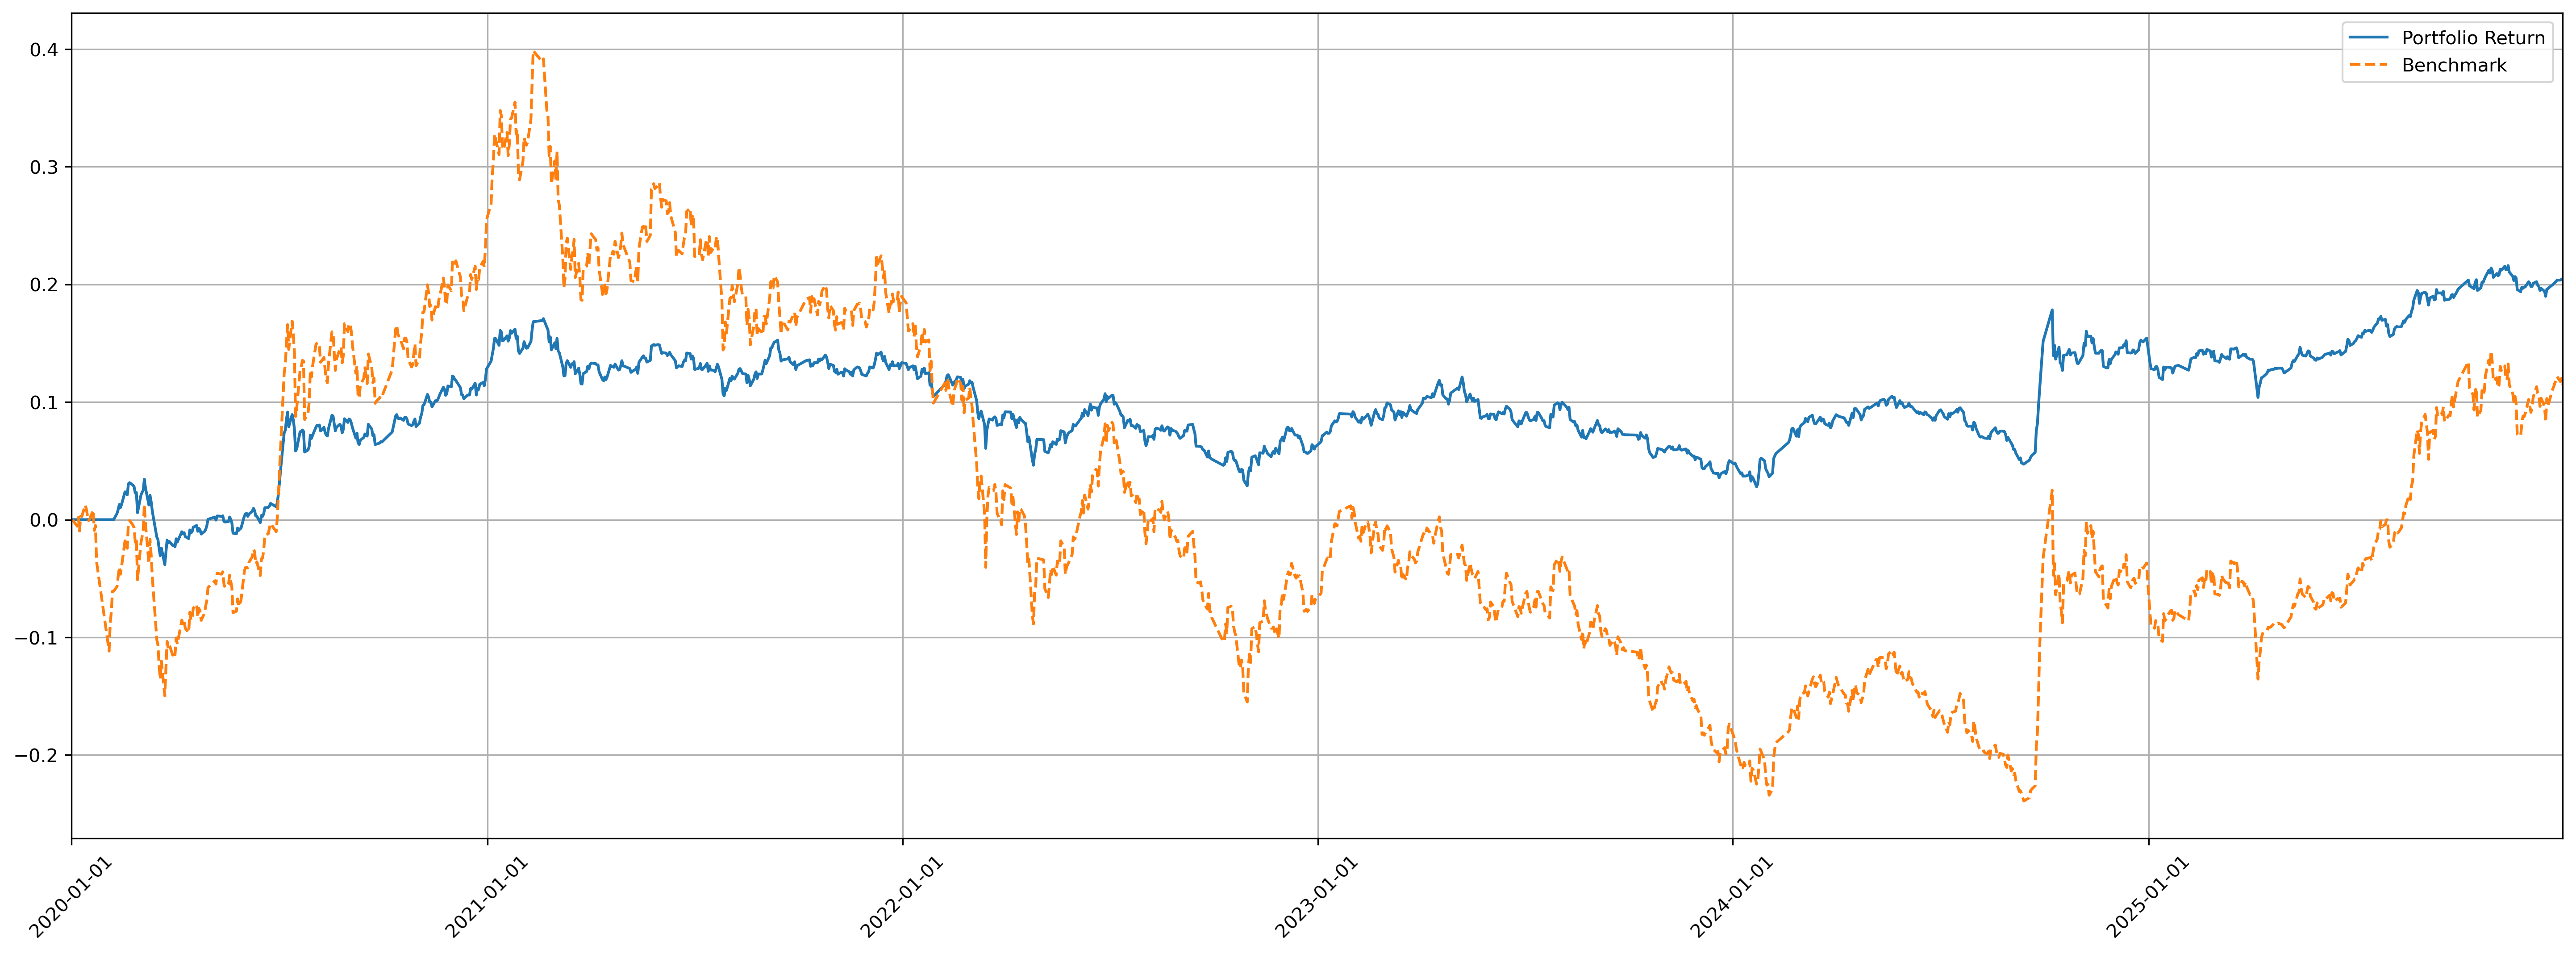

In [13]:
%matplotlib inline

stock_symbols = pd.read_csv('stock_symbols.csv')['symbol']
stock_symbols = {s: f'datas/{s}.csv' for s in stock_symbols}
fromdate = datetime.datetime(2020, 1, 1)
todate = datetime.datetime(2025, 12, 31)

if __name__ == '__main__':
    cerebro = bt.Cerebro()

    cerebro.addstrategy(TestStrategy)

    # 导入股票数据
    for symbol, stock in stock_symbols.items():
        data_df = pd.read_csv(stock, index_col = 0, parse_dates = True)

        # 表格数据类型用手动设置的继承 bt.feeds.PandasData 的带市值的数据类型 DataWithCap 类
        data = DataWithCap(
            dataname = data_df,
            fromdate = fromdate,
            todate = todate
        )
        cerebro.adddata(data, name = symbol)

    # 导入基准
    benchmark_df = pd.read_csv('datas/hs300.csv', index_col = 0, parse_dates = True)
    benchmark = bt.feeds.PandasData(
        dataname = benchmark_df,
        fromdate = fromdate,
        todate = todate
    )
    cerebro.adddata(benchmark, name = 'benchmark')

    cerebro.addobserver(bt.observers.Benchmark, data = benchmark)
    
    # 加入分析指标
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name = 'sharp_ratio')
    cerebro.addanalyzer(bt.analyzers.AnnualReturn, _name = 'annual_return')
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name = 'draw_down')

    # 设置 broker 的初始资金以及佣金
    cerebro.broker.setcash(100000.0)
    cerebro.broker.setcommission(commission = 0.001)

    print('Starting Portfolio Value: %.2f' % cerebro.broker.getvalue())

    # 执行策略并获取策略实例
    results = cerebro.run()
    strategy = results[0]

    # 计算收益率
    dates = strategy.dates
    portfolio_values = strategy.portfolio_values
    benchmark_values = strategy.benchmark_values

    portfolio_returns = pd.DataFrame(np.array(portfolio_values) / portfolio_values[0] - 1, index = dates)
    benchmark_returns = pd.DataFrame(np.array(benchmark_values) / benchmark_values[0] - 1, index = dates)

    portfolio_returns.index = pd.to_datetime(portfolio_returns.index)
    benchmark_returns.index = pd.to_datetime(benchmark_returns.index)

    # 导出指标
    sharp_ratio = strategy.analyzers.sharp_ratio.get_analysis()
    annual_return = strategy.analyzers.annual_return.get_analysis()
    draw_down = strategy.analyzers.draw_down.get_analysis()

    print('Final Portfolio Value: %.2f' % cerebro.broker.getvalue())
    pprint(sharp_ratio)
    pprint(annual_return)
    pprint(draw_down)

    # 绘图
    plt.figure(figsize = (24, 8))
    plt.plot(portfolio_returns, label = 'Portfolio Return')
    plt.plot(benchmark_returns, label = 'Benchmark', linestyle = '--')
    plt.xlim(fromdate, todate)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

    '''
    plt.rcParams['figure.figsize'] = (24, 36)
    plt.rcParams['figure.dpi'] = 300

    cerebro.plot(iplot = False, mpl = {'style': 'mpl'})
    '''
    